In [2]:
import torch
import torch.nn as nn
import numpy as np
from scipy.integrate import quad

In [3]:


# --- 1. Paramètres Physiques et Géométriques ---
a1, a2, a3 = 4.0, 1.5, 1.5  # Demi-axes (micromètres)
gamma_dot = 1.0             # Taux de cisaillement
lambda_visc = 5.0           # Rapport de viscosité interne/externe

def calculate_ks_constants(a1, a2, a3):
    v_rel = (a1 * a2 * a3)**(1/3)
    alpha1, alpha2, alpha3 = a1/v_rel, a2/v_rel, a3/v_rel
    
    def integrand(s):
        delta = np.sqrt((alpha1**2 + s) * (alpha2**2 + s) * (alpha3**2 + s))
        return 1 / ((alpha1**2 + s) * (alpha2**2 + s) * delta)
    
    g3_prime, _ = quad(integrand, 0, np.inf)
    z1 = 0.5 * (a1/a2 - a2/a1)
    z2 = g3_prime * (a1**2 + a2**2)
    
    f1 = (a1/a2 + a2/a1)**2
    f2 = 4 * (z1**2) * (1 - 2/z2)
    f3 = -4 * z1 / z2
    return f1, f2, f3

f1, f2, f3 = calculate_ks_constants(a1, a2, a3)
C_visc = -f3 / (f2 + lambda_visc * f1)
B_base = 0.5 * (a1**2 - a2**2) / (a1**2 + a2**2)

In [4]:
class FCN_Fluid(nn.Module):
    def __init__(self, N_INPUT=1, N_OUTPUT=2, N_HIDDEN=32, N_LAYERS=3):
        super().__init__()
        activation = nn.Tanh
        self.fcs = nn.Sequential(nn.Linear(N_INPUT, N_HIDDEN), activation())
        self.fch = nn.Sequential(*[
            nn.Sequential(nn.Linear(N_HIDDEN, N_HIDDEN), activation()) 
            for _ in range(N_LAYERS-1)
        ])
        self.fce = nn.Linear(N_HIDDEN, N_OUTPUT)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.fcs(x)
        x = self.fch(x)
        return self.fce(x)

In [7]:
# Préparation des données temporelles
period = 20.0
t_physics = torch.linspace(0, period, 500).view(-1, 1).requires_grad_(True)

# --- A. Augmenter la capacité du réseau ---
# Si les courbes oscillent trop (Image 1), le réseau manque peut-être de neurones
model = FCN_Fluid(N_INPUT=1, N_OUTPUT=2, N_HIDDEN=64, N_LAYERS=4) 

# --- B. Optimiseur L-BFGS musclé ---
optimizer = torch.optim.LBFGS(
    model.parameters(), 
    lr=1, 
    max_iter=50000, 
    tolerance_grad=1e-9, 
    history_size=50,
    line_search_fn="strong_wolfe"
)

# --- Variable de contrôle globale ---
step_counter = 0

def closure():
    global step_counter
    optimizer.zero_grad()
    
    pred = model(t_physics)
    theta = pred[:, 0:1]
    phi   = pred[:, 1:2]
    
    dtheta_dt = torch.autograd.grad(theta, t_physics, torch.ones_like(theta), create_graph=True)[0]
    dphi_dt   = torch.autograd.grad(phi, t_physics, torch.ones_like(phi), create_graph=True)[0]
    
    # Équations de Keller-Skalak
    res_phi = dphi_dt - gamma_dot * (C_visc * torch.cos(2 * theta))
    
    A_eff = -0.5 - (2*a1*a2 / (a1**2 + a2**2)) * (dphi_dt / gamma_dot)
    res_theta = dtheta_dt - gamma_dot * (A_eff + B_base * torch.cos(2 * theta))
    
    # Calcul des pertes individuelles
    loss_ph_theta = torch.mean(res_theta**2)
    loss_ph_phi   = torch.mean(res_phi**2)
    
    # Condition initiale
    ic_pred = model(torch.tensor([[0.0]]))
    loss_ic = torch.mean(ic_pred**2)
    
    # --- LOGIQUE DYNAMIQUE DU POIDS ---
    # On ajuste le poids de loss_ph_phi selon l'étape actuelle
    weight_theta = 10.0 if step_counter < 5 else 300.0
    
    total_loss =  weight_theta* loss_ph_theta +  1000.0* loss_ph_phi + 500.0 * loss_ic
    
    total_loss.backward()
    return total_loss

# --- Boucle d'optimisation ---
for i in range(10): 
    step_counter = i  # Mise à jour du compteur pour la closure
    loss = optimizer.step(closure)
    
    # Affichage du poids actuel pour vérification
    current_weight = 10.0 if i < 5 else 300.0
    print(f"Step {i} (Weight theta: {current_weight}): Loss {loss.item():.6f}")

Step 0 (Weight theta: 10.0): Loss 1.603426
Step 1 (Weight theta: 10.0): Loss 0.157080
Step 2 (Weight theta: 10.0): Loss 0.157080
Step 3 (Weight theta: 10.0): Loss 0.157080
Step 4 (Weight theta: 10.0): Loss 0.157080
Step 5 (Weight theta: 300.0): Loss 4.672027
Step 6 (Weight theta: 300.0): Loss 4.158833
Step 7 (Weight theta: 300.0): Loss 4.158833
Step 8 (Weight theta: 300.0): Loss 4.158833
Step 9 (Weight theta: 300.0): Loss 4.158833


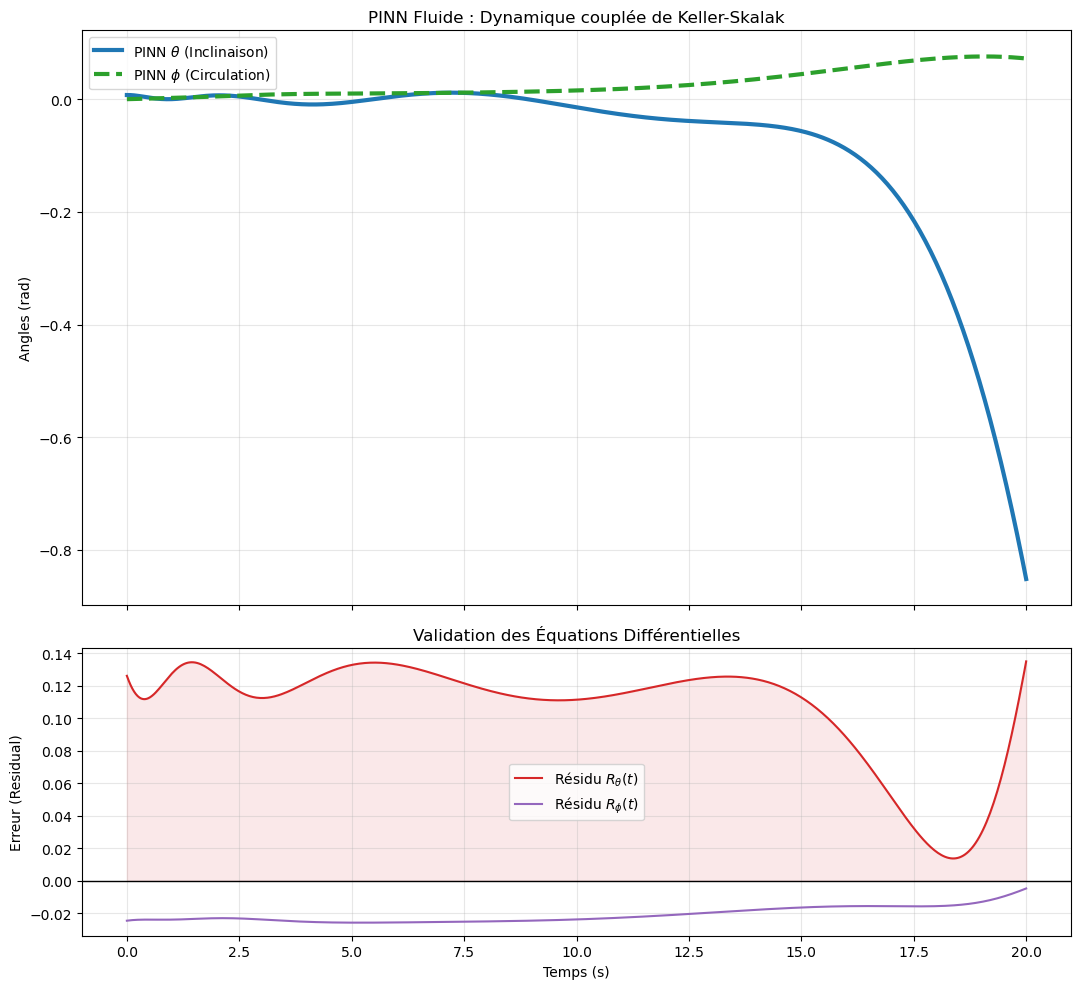

In [8]:
import matplotlib.pyplot as plt
import torch

# 1. Préparation des données de test
t_test = torch.linspace(0, period, 500).view(-1, 1).requires_grad_(True)
predictions = model(t_test)

# Séparation des prédictions [theta, phi]
theta_pred = predictions[:, 0:1]
phi_pred   = predictions[:, 1:2]

# 2. Calcul des dérivées et des résidus physiques
dtheta_dt_test = torch.autograd.grad(theta_pred, t_test, torch.ones_like(theta_pred), create_graph=True)[0]
dphi_dt_test   = torch.autograd.grad(phi_pred, t_test, torch.ones_like(phi_pred), create_graph=True)[0]

# Résidu phi : R_phi = dphi/dt - gamma_dot * C_visc * cos(2*theta)
residu_phi = (dphi_dt_test - gamma_dot * (C_visc * torch.cos(2 * theta_pred))).detach().cpu().numpy()

# Résidu theta : R_theta = dtheta/dt - gamma_dot * (A_eff + B_base * cos(2*theta))
A_eff_test = -0.5 - (2*a1*a2 / (a1**2 + a2**2)) * (dphi_dt_test / gamma_dot)
residu_theta = (dtheta_dt_test - gamma_dot * (A_eff_test + B_base * torch.cos(2 * theta_pred))).detach().cpu().numpy()

# 3. Conversion pour NumPy
t_plot = t_test.detach().cpu().numpy()
theta_plot = theta_pred.detach().cpu().numpy()
phi_plot = phi_pred.detach().cpu().numpy()

# --- Création de la Figure ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 10), sharex=True, 
                               gridspec_kw={'height_ratios': [2, 1]})

# --- SUBPLOT 1 : Solutions (θ et φ) ---
# On trace l'inclinaison (theta) et la circulation (phi)
ax1.plot(t_plot, theta_plot, color="tab:blue", linewidth=3, label=r"PINN $\theta$ (Inclinaison)")
ax1.plot(t_plot, phi_plot, color="tab:green", linewidth=3, linestyle="--", label=r"PINN $\phi$ (Circulation)")

# Si tu as des données de référence (y_data pour theta par exemple)
# ax1.scatter(t_data_plot, y_data_plot, color="tab:orange", label="Data", zorder=5)

ax1.set_ylabel("Angles (rad)")
ax1.set_title("PINN Fluide : Dynamique couplée de Keller-Skalak")
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- SUBPLOT 2 : Résidus Physiques ---
# On trace les deux résidus pour vérifier l'EDO
ax2.plot(t_plot, residu_theta, color="tab:red", linewidth=1.5, label=r"Résidu $R_{\theta}(t)$")
ax2.plot(t_plot, residu_phi, color="tab:purple", linewidth=1.5, label=r"Résidu $R_{\phi}(t)$")
ax2.fill_between(t_plot.flatten(), residu_theta.flatten(), color="tab:red", alpha=0.1)

ax2.axhline(0, color='black', lw=1, linestyle='-')
ax2.set_xlabel("Temps (s)")
ax2.set_ylabel("Erreur (Residual)")
ax2.set_title("Validation des Équations Différentielles")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# Préparation des données temporelles
period = 20.0
t_physics = torch.linspace(0, period, 500).view(-1, 1).requires_grad_(True)

# --- A. Augmenter la capacité du réseau ---
# Si les courbes oscillent trop (Image 1), le réseau manque peut-être de neurones
model = FCN_Fluid(N_INPUT=1, N_OUTPUT=2, N_HIDDEN=64, N_LAYERS=4) 

# --- B. Optimiseur L-BFGS musclé ---
optimizer = torch.optim.LBFGS(
    model.parameters(), 
    lr=1, 
    max_iter=50000, 
    tolerance_grad=1e-9, 
    history_size=50,
    line_search_fn="strong_wolfe"
)

# --- Variable de contrôle globale ---
step_counter = 0

def closure():
    global step_counter
    optimizer.zero_grad()
    
    pred = model(t_physics)
    theta = pred[:, 0:1]
    phi   = pred[:, 1:2]
    
    dtheta_dt = torch.autograd.grad(theta, t_physics, torch.ones_like(theta), create_graph=True)[0]
    dphi_dt   = torch.autograd.grad(phi, t_physics, torch.ones_like(phi), create_graph=True)[0]
    
    # Équations de Keller-Skalak
    res_phi = dphi_dt - gamma_dot * (C_visc * torch.cos(2 * theta))
    
    A_eff = -0.5 - (2*a1*a2 / (a1**2 + a2**2)) * (dphi_dt / gamma_dot)
    res_theta = dtheta_dt - gamma_dot * (A_eff + B_base * torch.cos(2 * theta))
    
    # Calcul des pertes individuelles
    loss_ph_theta = torch.mean(res_theta**2)
    loss_ph_phi   = torch.mean(res_phi**2)
    
    # Condition initiale
    ic_pred = model(torch.tensor([[0.0]]))
    loss_ic = torch.mean(ic_pred**2)
    
    # --- LOGIQUE DYNAMIQUE DU POIDS ---
    # On ajuste le poids de loss_ph_phi selon l'étape actuelle
    weight_phi = 1000.0 if step_counter < 5 else 1000.0
    
    total_loss = 1000.0 * loss_ph_theta + weight_phi * loss_ph_phi + 500.0 * loss_ic
    
    total_loss.backward()
    return total_loss

# --- Boucle d'optimisation ---
for i in range(10): 
    step_counter = i  # Mise à jour du compteur pour la closure
    loss = optimizer.step(closure)
    
    # Affichage du poids actuel pour vérification
    current_weight = 1000.0 if i < 5 else 1000.0
    print(f"Step {i} (Weight Phi: {current_weight}): Loss {loss.item():.6f}")

Step 0 (Weight Phi: 1000.0): Loss 65.434174
Step 1 (Weight Phi: 1000.0): Loss 11.113426
Step 2 (Weight Phi: 1000.0): Loss 11.113426
Step 3 (Weight Phi: 1000.0): Loss 11.113426
Step 4 (Weight Phi: 1000.0): Loss 11.113426
Step 5 (Weight Phi: 1000.0): Loss 11.113426
Step 6 (Weight Phi: 1000.0): Loss 11.113426
Step 7 (Weight Phi: 1000.0): Loss 11.113426
Step 8 (Weight Phi: 1000.0): Loss 11.113426
Step 9 (Weight Phi: 1000.0): Loss 11.113426


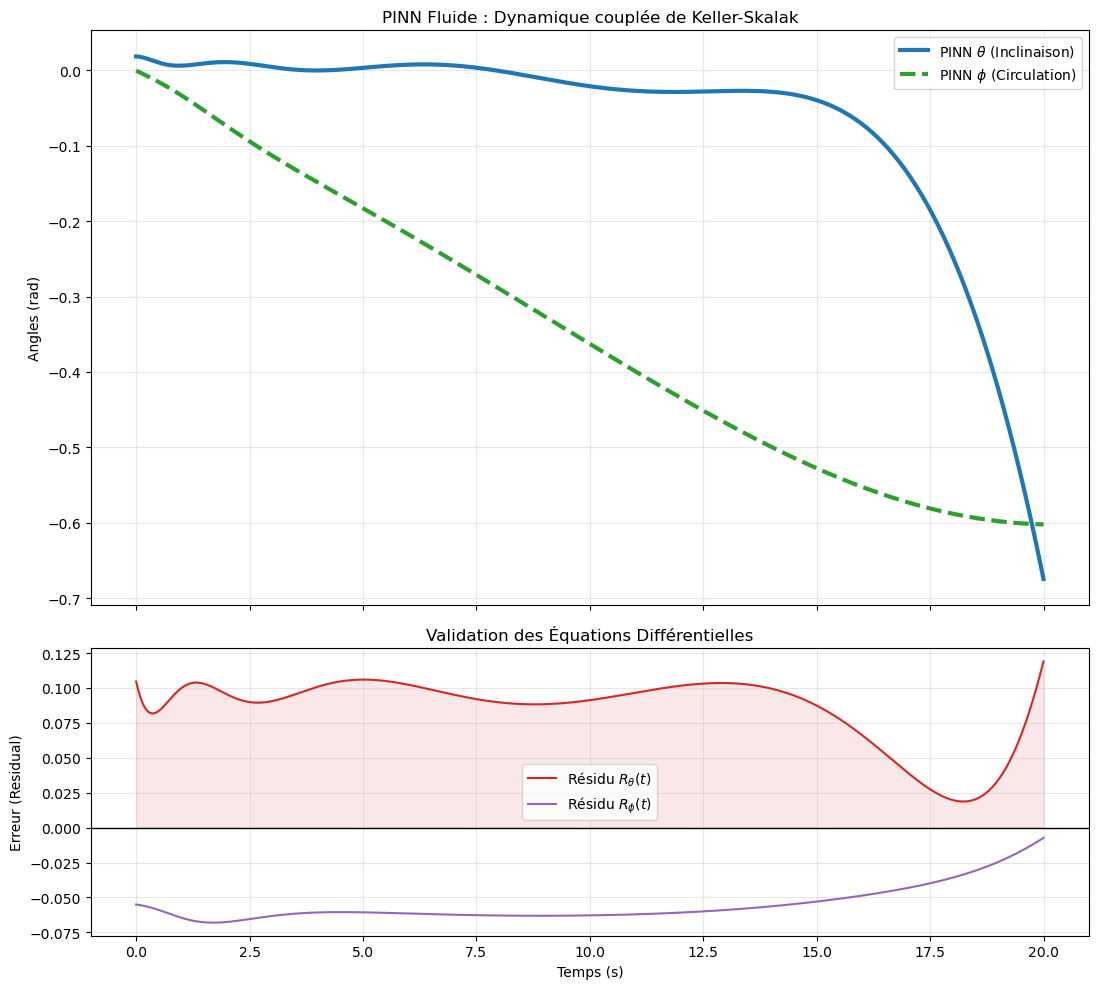

In [15]:
import matplotlib.pyplot as plt
import torch

# 1. Préparation des données de test
t_test = torch.linspace(0, period, 500).view(-1, 1).requires_grad_(True)
predictions = model(t_test)

# Séparation des prédictions [theta, phi]
theta_pred = predictions[:, 0:1]
phi_pred   = predictions[:, 1:2]

# 2. Calcul des dérivées et des résidus physiques
dtheta_dt_test = torch.autograd.grad(theta_pred, t_test, torch.ones_like(theta_pred), create_graph=True)[0]
dphi_dt_test   = torch.autograd.grad(phi_pred, t_test, torch.ones_like(phi_pred), create_graph=True)[0]

# Résidu phi : R_phi = dphi/dt - gamma_dot * C_visc * cos(2*theta)
residu_phi = (dphi_dt_test - gamma_dot * (C_visc * torch.cos(2 * theta_pred))).detach().cpu().numpy()

# Résidu theta : R_theta = dtheta/dt - gamma_dot * (A_eff + B_base * cos(2*theta))
A_eff_test = -0.5 - (2*a1*a2 / (a1**2 + a2**2)) * (dphi_dt_test / gamma_dot)
residu_theta = (dtheta_dt_test - gamma_dot * (A_eff_test + B_base * torch.cos(2 * theta_pred))).detach().cpu().numpy()

# 3. Conversion pour NumPy
t_plot = t_test.detach().cpu().numpy()
theta_plot = theta_pred.detach().cpu().numpy()
phi_plot = phi_pred.detach().cpu().numpy()

# --- Création de la Figure ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 10), sharex=True, 
                               gridspec_kw={'height_ratios': [2, 1]})

# --- SUBPLOT 1 : Solutions (θ et φ) ---
# On trace l'inclinaison (theta) et la circulation (phi)
ax1.plot(t_plot, theta_plot, color="tab:blue", linewidth=3, label=r"PINN $\theta$ (Inclinaison)")
ax1.plot(t_plot, phi_plot, color="tab:green", linewidth=3, linestyle="--", label=r"PINN $\phi$ (Circulation)")

# Si tu as des données de référence (y_data pour theta par exemple)
# ax1.scatter(t_data_plot, y_data_plot, color="tab:orange", label="Data", zorder=5)

ax1.set_ylabel("Angles (rad)")
ax1.set_title("PINN Fluide : Dynamique couplée de Keller-Skalak")
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- SUBPLOT 2 : Résidus Physiques ---
# On trace les deux résidus pour vérifier l'EDO
ax2.plot(t_plot, residu_theta, color="tab:red", linewidth=1.5, label=r"Résidu $R_{\theta}(t)$")
ax2.plot(t_plot, residu_phi, color="tab:purple", linewidth=1.5, label=r"Résidu $R_{\phi}(t)$")
ax2.fill_between(t_plot.flatten(), residu_theta.flatten(), color="tab:red", alpha=0.1)

ax2.axhline(0, color='black', lw=1, linestyle='-')
ax2.set_xlabel("Temps (s)")
ax2.set_ylabel("Erreur (Residual)")
ax2.set_title("Validation des Équations Différentielles")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [33]:
# Préparation des données temporelles
period = 20.0
t_physics = torch.linspace(0, period, 500).view(-1, 1).requires_grad_(True)

# --- A. Augmenter la capacité du réseau ---
# Si les courbes oscillent trop (Image 1), le réseau manque peut-être de neurones
model = FCN_Fluid(N_INPUT=1, N_OUTPUT=2, N_HIDDEN=64, N_LAYERS=4) 

# --- B. Optimiseur L-BFGS musclé ---
optimizer = torch.optim.LBFGS(
    model.parameters(), 
    lr=1, 
    max_iter=50000, 
    tolerance_grad=1e-9, 
    history_size=50,
    line_search_fn="strong_wolfe"
)

# --- Variable de contrôle globale ---
step_counter = 0

def closure():
    global step_counter
    optimizer.zero_grad()
    
    pred = model(t_physics)
    theta = pred[:, 0:1]
    phi   = pred[:, 1:2]
    
    dtheta_dt = torch.autograd.grad(theta, t_physics, torch.ones_like(theta), create_graph=True)[0]
    dphi_dt   = torch.autograd.grad(phi, t_physics, torch.ones_like(phi), create_graph=True)[0]
    
    # Équations de Keller-Skalak
    res_phi = dphi_dt - gamma_dot * (C_visc * torch.cos(2 * theta))
    
    A_eff = -0.5 - (2*a1*a2 / (a1**2 + a2**2)) * (dphi_dt / gamma_dot)
    res_theta = dtheta_dt - gamma_dot * (A_eff + B_base * torch.cos(2 * theta))
    
    # Calcul des pertes individuelles
    loss_ph_theta = torch.mean(res_theta**2)
    loss_ph_phi   = torch.mean(res_phi**2)
    
    # Condition initiale
    ic_pred = model(torch.tensor([[0.0]]))
    loss_ic = torch.mean(ic_pred**2)
    
    # --- LOGIQUE DYNAMIQUE DU POIDS ---
    # On ajuste le poids de loss_ph_phi selon l'étape actuelle
    weight_phi = 10.0 if step_counter < 5 else 300.0
    
    total_loss = 1000.0 * loss_ph_theta + weight_phi * loss_ph_phi + 500.0 * loss_ic
    
    total_loss.backward()
    return total_loss

# --- Boucle d'optimisation ---
for i in range(10): 
    step_counter = i  # Mise à jour du compteur pour la closure
    loss = optimizer.step(closure)
    
    # Affichage du poids actuel pour vérification
    current_weight = 10.0 if i < 5 else 300.0
    print(f"Step {i} (Weight Phi: {current_weight}): Loss {loss.item():.6f}")

Step 0 (Weight Phi: 10.0): Loss 419.579376
Step 1 (Weight Phi: 10.0): Loss 0.000331
Step 2 (Weight Phi: 10.0): Loss 0.000331
Step 3 (Weight Phi: 10.0): Loss 0.000331
Step 4 (Weight Phi: 10.0): Loss 0.000331
Step 5 (Weight Phi: 300.0): Loss 0.005483
Step 6 (Weight Phi: 300.0): Loss 0.000098
Step 7 (Weight Phi: 300.0): Loss 0.000098
Step 8 (Weight Phi: 300.0): Loss 0.000098
Step 9 (Weight Phi: 300.0): Loss 0.000098


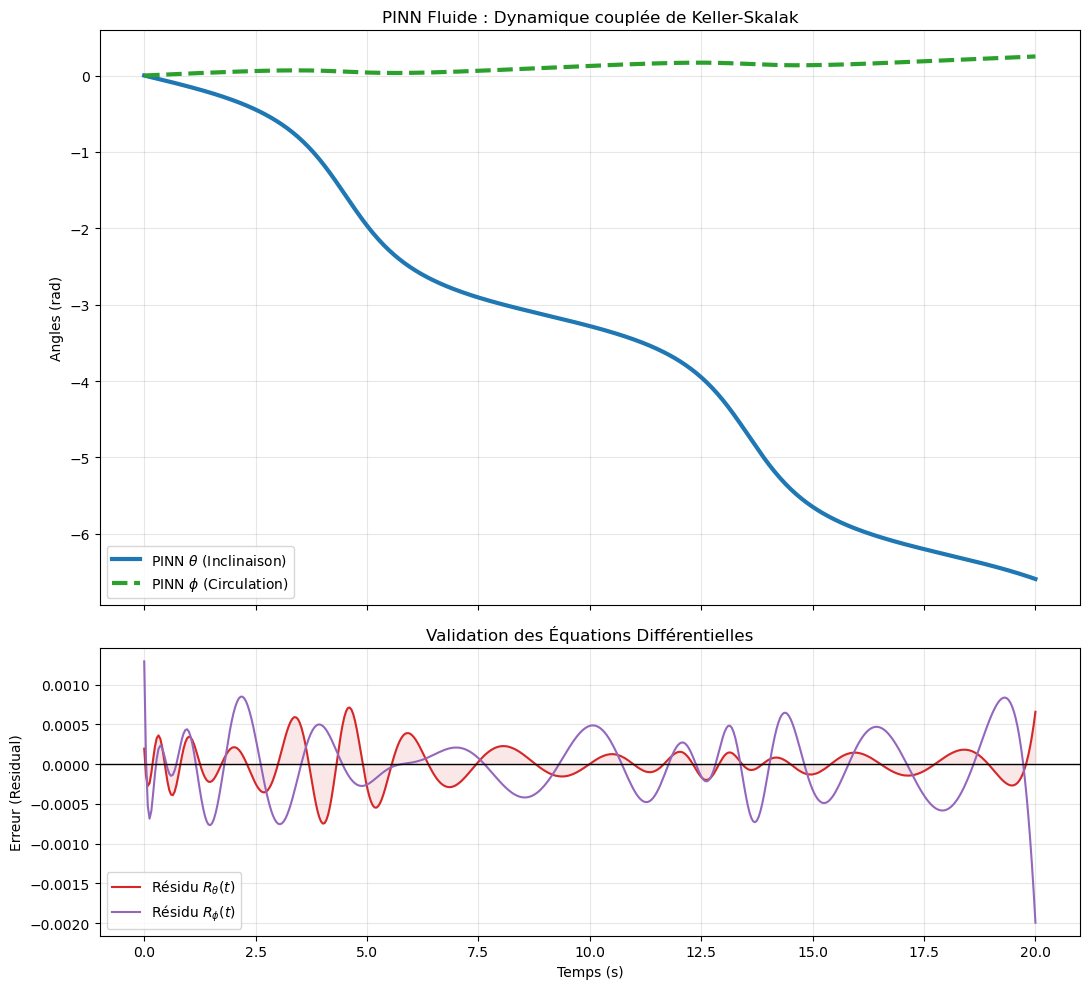

In [34]:
import matplotlib.pyplot as plt
import torch

# 1. Préparation des données de test
t_test = torch.linspace(0, period, 500).view(-1, 1).requires_grad_(True)
predictions = model(t_test)

# Séparation des prédictions [theta, phi]
theta_pred = predictions[:, 0:1]
phi_pred   = predictions[:, 1:2]

# 2. Calcul des dérivées et des résidus physiques
dtheta_dt_test = torch.autograd.grad(theta_pred, t_test, torch.ones_like(theta_pred), create_graph=True)[0]
dphi_dt_test   = torch.autograd.grad(phi_pred, t_test, torch.ones_like(phi_pred), create_graph=True)[0]

# Résidu phi : R_phi = dphi/dt - gamma_dot * C_visc * cos(2*theta)
residu_phi = (dphi_dt_test - gamma_dot * (C_visc * torch.cos(2 * theta_pred))).detach().cpu().numpy()

# Résidu theta : R_theta = dtheta/dt - gamma_dot * (A_eff + B_base * cos(2*theta))
A_eff_test = -0.5 - (2*a1*a2 / (a1**2 + a2**2)) * (dphi_dt_test / gamma_dot)
residu_theta = (dtheta_dt_test - gamma_dot * (A_eff_test + B_base * torch.cos(2 * theta_pred))).detach().cpu().numpy()

# 3. Conversion pour NumPy
t_plot = t_test.detach().cpu().numpy()
theta_plot = theta_pred.detach().cpu().numpy()
phi_plot = phi_pred.detach().cpu().numpy()

# --- Création de la Figure ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 10), sharex=True, 
                               gridspec_kw={'height_ratios': [2, 1]})

# --- SUBPLOT 1 : Solutions (θ et φ) ---
# On trace l'inclinaison (theta) et la circulation (phi)
ax1.plot(t_plot, theta_plot, color="tab:blue", linewidth=3, label=r"PINN $\theta$ (Inclinaison)")
ax1.plot(t_plot, phi_plot, color="tab:green", linewidth=3, linestyle="--", label=r"PINN $\phi$ (Circulation)")

# Si tu as des données de référence (y_data pour theta par exemple)
# ax1.scatter(t_data_plot, y_data_plot, color="tab:orange", label="Data", zorder=5)

ax1.set_ylabel("Angles (rad)")
ax1.set_title("PINN Fluide : Dynamique couplée de Keller-Skalak")
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- SUBPLOT 2 : Résidus Physiques ---
# On trace les deux résidus pour vérifier l'EDO
ax2.plot(t_plot, residu_theta, color="tab:red", linewidth=1.5, label=r"Résidu $R_{\theta}(t)$")
ax2.plot(t_plot, residu_phi, color="tab:purple", linewidth=1.5, label=r"Résidu $R_{\phi}(t)$")
ax2.fill_between(t_plot.flatten(), residu_theta.flatten(), color="tab:red", alpha=0.1)

ax2.axhline(0, color='black', lw=1, linestyle='-')
ax2.set_xlabel("Temps (s)")
ax2.set_ylabel("Erreur (Residual)")
ax2.set_title("Validation des Équations Différentielles")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()